## Final Project

### Due date 5/05/26 at 7:00 pm (see Canvas Assignment).

#### <span style="background-color: #FFFF00">The final project has only a due date (see Canvas schedule). There is no late date. No extensions will be granted without a UAA from the Dean of Students, and submissions after the due date will not be accepted. Please submit it well before the 7:00 pm deadline to avoid any issues.</span>

****

## Collaboration policy

This is a **group project** and the team assignments are posted on this Canvas assignment webpage.  **If your name does not appear in a group, you must contact Brent (a private Piazza post) by 11:55 pm, Friday, April. 24th.** Please be welcoming and kind to the students in your group (i.e., be a good classmate).

Please be **welcoming and considerate** when forming groups. You are encouraged to reach out to classmates you may not know well and to act as a supportive, inclusive member of the class. If you are unsure about what is or is not allowed, **you must ask for clarification in advance**. Claiming confusion or uncertainty after the fact will not be accepted as an excuse.

**Collaboration is permitted only within your team.** There may be **no collaboration, discussion, or sharing of work between different teams**. All submitted work must be **entirely the product of your own team**.

To ensure fairness for everyone, the **collaboration policy will be strictly enforced**. Any violation may result in **a zero for all students involved**.

In the Markdown cell below, list the full names of all members of your group.


### Team members

1. Suhas Puttoju
2. Nabiha Choudhury

****
## AI policy

AI may not be used to generate a coding solution. Your solution must be your own work. If you have any questions about what is or isn't allowed, you must ask. Saying afterward that you didn't understand or were unsure is not an acceptable excuse.

To ensure fairness for everyone, the **AI policy will be strictly enforced**. Any violation may result in **a zero for all students involved**.



****
## Honor pledge

To acknowledge and understand the **Collaboration and AI policies** outlined above, each team member must enter their Onyen and PID in this markdown cell.

1. suhasp 730672627
2. chnabi 73659209

****

## Python modules

All the Python modules needed to complete this project are provided to you. 

<span style="background-color: #FFFF00">**No other modules are authorized** and **if other modules are added points will be deducted**.</span>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans as kmeans
import pandas as pd 
import math
import warnings
warnings.filterwarnings('ignore')

****

### Latent Face Indexing and Expression Retrieval.

Identical to project two, the provided dataframe (**fdf**) is a $2n \times m$ matrix of face data, where the columns represent shape vectors (e.g., ${\bf f}_i$ is the column vector that represents the i<sup>th</sup> face in the dataset), and the rows represent landmarks on a $2$D human face (<a href="https://ibug.doc.ic.ac.uk/resources/facial-point-annotations/">data reference</a>). Specifically, the $2n$-dimension column vector ${\bf f}_1=(x_0,y_0,x_1,y_1, \ldots, x_i, y_i, \ldots, x_{n-1}, y_{n-1})$ defines $n=68$ landmark locations on face $1$ (column named **f1**) in the dataset.

In general, the concepts from the latent semantic indexing paper (see the reference below) are applied to the face data. Specifically, low-dimensional latent relationships will be uncovered in the $2n \times m$ **landmark-face** matrix (instead of the term-document matrix) using singular value decomposition (SVD). Then, we will use these relationships to retrieve faces with similar **expressions** that are learned in the lower-dimensional latent space.

**Tips**:
- The latent semantic indexing <a href="https://uncch.instructure.com/courses/93717/pages/schedule">paper</a> that was published in 1990 (see the Canvas schedule).
- The example LSI <a href="https://uncch.instructure.com/courses/93717/files/13075742?wrap=1">notebook</a> (see the Canvas schedule, **highly recommended**).

****

In [3]:
fdf = pd.read_csv("F.csv" )
fdf

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f178,f179,f180,f181,f182,f183,f184,f185,f186,f187
0,-1.000000,-1.000000,-1.000000,-1.000000,-0.951937,-0.996250,-0.962643,-0.973699,-1.000000,-1.000000,...,-0.928993,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-0.950060,-0.914484,-1.000000,-1.000000
1,1.000000,0.832926,0.579261,0.231897,0.565381,0.849546,0.858178,0.817682,0.729727,0.467076,...,0.648711,0.724321,0.421352,0.711271,0.694059,0.490634,0.536417,-0.350551,0.507698,0.192629
2,-0.965634,-0.970360,-0.983060,-0.952045,-1.000000,-1.000000,-1.000000,-1.000000,-0.987371,-0.920799,...,-0.980922,-0.935998,-0.910346,-0.930497,-0.987213,-0.931974,-0.970648,-0.827805,-0.919498,-0.948147
3,0.685826,0.487520,0.318358,0.015101,0.318405,0.520962,0.511738,0.573777,0.457303,0.144798,...,0.468704,0.472606,0.179666,0.394879,0.403099,0.196641,0.289123,-0.509708,0.248383,-0.064326
4,-0.950751,-0.838847,-0.969005,-0.868485,-0.998650,-0.950642,-0.973317,-0.983797,-0.953697,-0.823358,...,-1.000000,-0.876227,-0.880468,-0.920069,-0.965791,-0.841766,-0.925714,-0.758012,-0.846001,-0.902248
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,-0.626924,-0.361757,-0.318876,-0.502801,-0.363823,-0.371101,-0.203414,-0.346591,-0.456504,-0.341847,...,-0.386944,-0.500128,-0.446003,-0.425400,-0.380385,-0.503704,-0.585163,-0.215784,-0.312186,-0.374595
132,0.107520,0.113745,-0.153760,0.375983,-0.400380,0.043260,0.289086,0.090587,-0.157003,0.419915,...,-0.386670,0.402114,0.220366,0.389456,-0.008135,0.521426,-0.202704,-0.024853,0.553613,0.464788
133,-0.657572,-0.404557,-0.350701,-0.541314,-0.374537,-0.380429,-0.226528,-0.379223,-0.459393,-0.354035,...,-0.380905,-0.533512,-0.437627,-0.407400,-0.384911,-0.576235,-0.591528,-0.292822,-0.317218,-0.390096
134,0.013293,0.001258,-0.270076,0.253130,-0.501222,-0.075586,0.177918,-0.020670,-0.264473,0.290111,...,-0.489210,0.263180,0.075984,0.263974,-0.097492,0.399933,-0.287718,-0.116465,0.453454,0.403976


****

**P1** (10 Points): Latent face spaces.

<img src="p1.png" width="600" style="float: right"/>

Using the **fdf** dataframe, first randomly shuffle the columns (i.e., faces) and then split the shuffled data into training and testing matrices. The split is very simple. The shuffled training matrix will contain 185 faces from the first 185 columns (0 to 184), and the shuffled testing matrix will contain 3 faces from the last 3 columns (185 to 187).

The singular value decomposition (SVD) unsupervised learning method <span style="background-color: #FFFF00">will be applied to the training matrix</span>, and three low-dimensional latent spaces (using the data in the right singular vector matrix $V$) will be generated and visualized. Specifically,
- **A PC1 and PC2 latent space**. This space includes data represented by the first and second columns of $V$ (i.e., the columns associated with the largest and second-largest singular values).
- **A PC2 and PC3 latent space**. This space includes the data represented by the second and third columns in $V$ (i.e., the columns associated with the second and third-largest singular values).
- **A PC3 and PC4 latent space**. This space includes data represented by the third and fourth columns in $V$ (i.e., the columns associated with the third and fourth-largest singular values).

To receive full credit, your solution should produce plots similar to the reference plots. 

**Notes**:
- Only the training data is used to generate the scatter plots.
- You **must** use singular value decomposition (SVD).
- You may use the SVD function (<a href="https://numpy.org/doc/stable/reference/generated/numpy.linalg.svd.html">reference</a>) included in the NumPy library.
- The **svd** NumPy function will sort the singular value matrix ($S$) and its corresponding right ($V$) and left ($U$) singular vector matrices in descending order.
- Don't forget to undo the right singular vector matrix ($V$) transpose after SVD is performed.
- <span style="background-color: #FFFF00">Your plots won't be identical because the training data is a random shuffling of the dataframe</span>.
- **If you have questions or are unsure, you and your teammates must ask**.

**Plot assumptions**:
- The plot figure size is **15** inches in width and **5** inches in height.
- The plots must be placed in a $1 \times 3$ grid pattern (see reference plots).
- The color used to generate the plot is ``dimgray``.
- The label font size is $11$.
- The marker shape is **o**.
- The marker size is $50$.
- The marker alpha (opacity) value is set to $0.5$.
- The plot uses a tight layout (<a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.tight_layout.html">reference</a>).


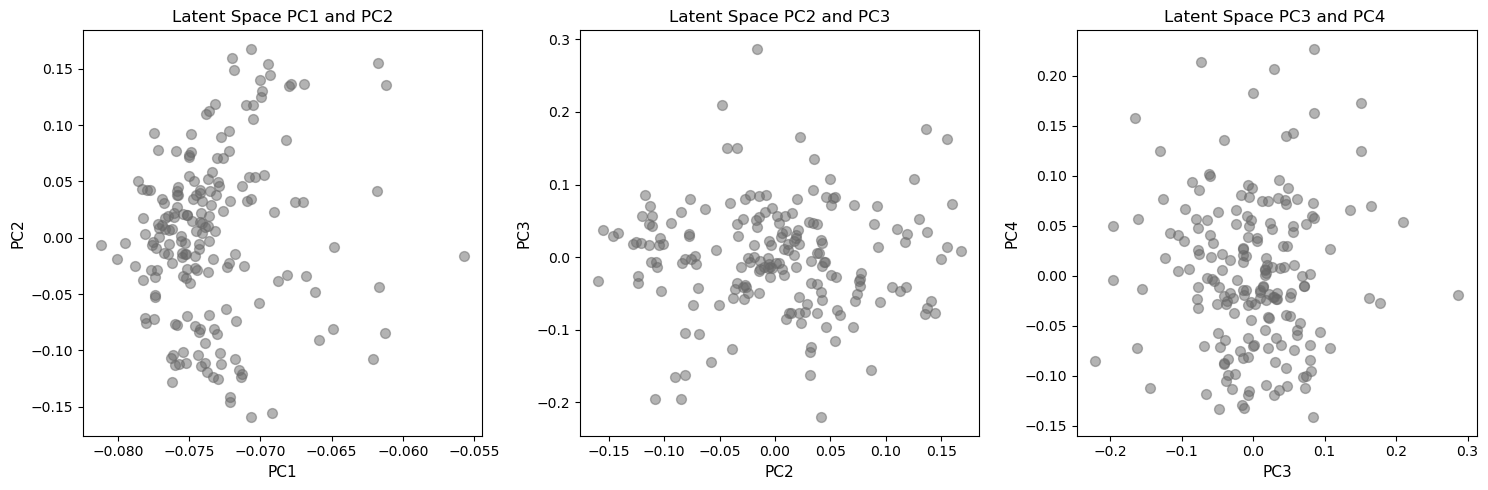

In [4]:
# --------------------------------------
# Add your P1 coding solution below.
# --------------------------------------
fdf_shuffled = fdf.sample(frac=1, axis=1)
fdf_train = fdf_shuffled.iloc[:, :185]
fdf_test = fdf_shuffled.iloc[:, 185:]

U, S, Vh = np.linalg.svd(fdf_train, full_matrices=False)
V = Vh.T

pc1, pc2, pc3, pc4 = V[:, 0], V[:, 1], V[:, 2], V[:, 3]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

for ax, (x, y, xl, yl) in zip(axes, [(pc1,pc2,"PC1","PC2"),(pc2,pc3,"PC2","PC3"),(pc3,pc4,"PC3","PC4")]):
    ax.scatter(x, y, c="dimgray", marker="o", s=50, alpha=0.5)
    ax.set_xlabel(xl, fontsize=11)
    ax.set_ylabel(yl, fontsize=11)
axes[0].set_title('Latent Space PC1 and PC2')
axes[1].set_title('Latent Space PC2 and PC3')
axes[2].set_title('Latent Space PC3 and PC4 ')
plt.tight_layout()
plt.show()
















****

**P2** (10 Points): Learning facial expressions.

<img src="p2.png" width="600" style="float: right"/>

Using the data generated in **P1**,the k-means unsupervised learning method is used to learn three facial expressions in each low-dimensional latent space, as shown in the reference plots.

Specifically, in each latent space: 
- The k-means method will identify **three** facial expression clusters, represented by blue, red, and green colors (the **\*** marker indicates the cluster centroid).
- For each facial expression cluster, facial expression plots are generated by averaging landmark points.

To receive full credit, your solution should produce plots similar to the reference plots. 

**Notes**:
- <span style="background-color: #FFFF00">A row in the right singular vector matrix $V$ corresponds to a column in the training data (i.e., they represent the same face).</span>

- You may use the k-means function (<a href="https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html">reference</a>) included in the Sklearn library (see Python modules above).
- The **n_clusters** and **n_init** k-means parameters are $3$ and $10$, respectively (all others are the default value).
- <span style="background-color: #FFFF00">Your plots won't be identical because the training data is a random shuffling of the dataframe (see P1)</span>.
- **If you have questions or are unsure, you and your teammates must ask**.

**Plot assumptions**:
- The plot figure size is **15** inches in width and **20** inches in height.
- The plots must be placed in a $3 \times 4$ grid pattern (see reference plots).
- The color used to generate the plots is ``blue``, ``red``, and ``green``.
- The default x-axis and y-axis tick values are removed (<a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.xticks.html">reference</a>).
- For marker shape **o** in the latent plot, the size is $50$ and the alpha (opacity) is $0.15$.
- For marker shape **\*** in the latent plot, the size is $15$.
- For marker shape **o** in the expression plots, the size is $50$.
- The plot axis is ``equal``.
- The plot uses a tight layout (<a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.tight_layout.html">reference</a>).


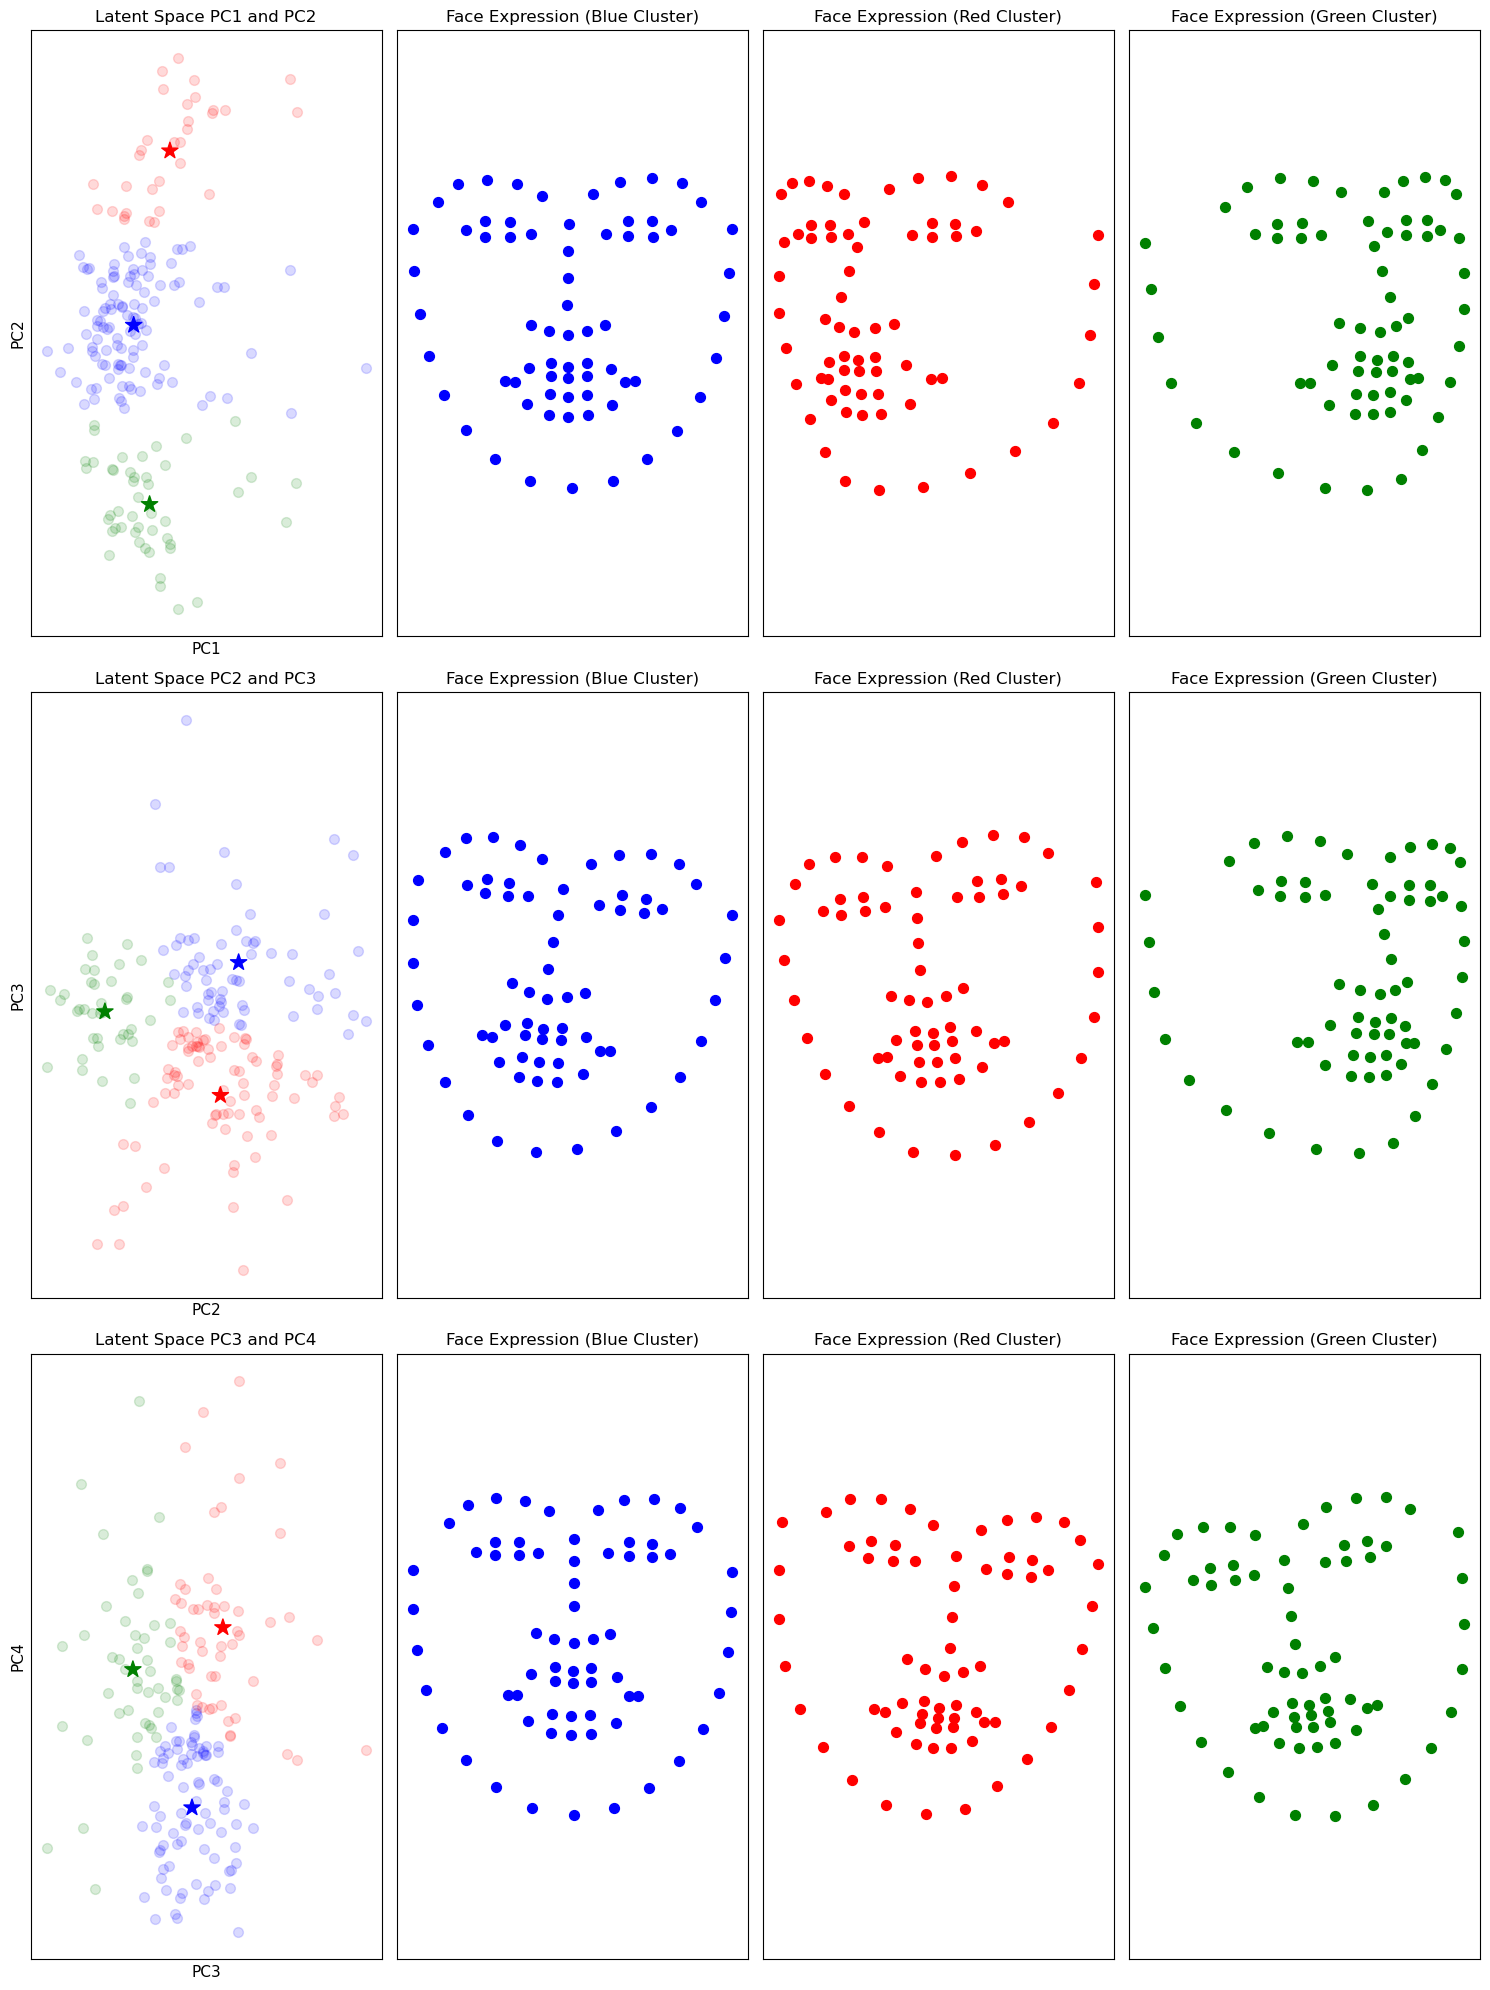

In [5]:
# --------------------------------------
# Add your P2 coding solution below.
# --------------------------------------

kmeans_models = []
all_clusters = []
all_centers = []

stacks = [
    np.column_stack([pc1, pc2]),
    np.column_stack([pc2, pc3]),
    np.column_stack([pc3, pc4])
]

for stack in stacks:
    km = kmeans(n_clusters=3, n_init=10)
    clusters = km.fit_predict(stack)
    kmeans_models.append(km)
    all_clusters.append(clusters)
    all_centers.append(km.cluster_centers_)

fig, axes = plt.subplots(3, 4, figsize=(15, 20))
colors = [ 'Blue', 'Red', 'Green']
pc_labels = [("PC1", "PC2"), ("PC2", "PC3"), ("PC3", "PC4")]

for row in range(3):  
    clusters = all_clusters[row]
    centers = all_centers[row]
    stack = stacks[row]
    pc_x, pc_y = pc_labels[row]
    
   
    ax = axes[row, 0]
    for cluster_id in range(3):
        mask = clusters == cluster_id
        points = stack[mask] 
        ax.scatter(points[:, 0], points[:, 1], c=colors[cluster_id], 
                  marker='o', s=50, alpha=0.15)
    ax.scatter(centers[:, 0], centers[:, 1], c=colors, marker='*', s=150)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"Latent Space {pc_labels[row][0]} and {pc_labels[row][1]}")
    ax.set_xlabel(pc_x, fontsize=11)  
    ax.set_ylabel(pc_y, fontsize=11)

    
    for cluster_id in range(3):
        ax = axes[row, cluster_id + 1]
        mask = clusters == cluster_id
        
        cluster_faces = fdf_train.iloc[:, mask].values
        avg_face = np.mean(cluster_faces, axis=1)
        
        ax.scatter(avg_face[::2], avg_face[1::2], c=colors[cluster_id], 
                  marker='o', s=50)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"Face Expression ({colors[cluster_id]} Cluster)")
        ax.set_aspect('equal', adjustable='datalim')

plt.tight_layout()
plt.show()



 














****

**P3** (10 Points): Facial expression retrieval.

<img src="p3.png" width="600" style="float: right"/>

Using the facial expression clusters learned in **P2**, for each query face in the testing dataset, the matching facial expression is retrieved from each low-dimensional latent space. Specifically, first, the query face is projected into the latent space, then the L2 distance to each cluster center is calculated, and the facial expression corresponding to the nearest cluster is retrieved.

To receive full credit, your solution should produce plots similar to the reference plots. 

**Notes**:
- <span style="background-color: #FFFF00">Projecting a query vector into the low-dimension latent space is outlined in the LSI paper, and an example is provided in the notebook</span> (see Tips).
- Manually compute the L2 (Euclidean) distance (i.e., **do not** use any numpy function).
- <span style="background-color: #FFFF00">Your plots won't be identical because the testing and training data are a random shuffling of the dataframe (see P1)</span>.
- **If you have questions or are unsure, you and your teammates must ask**.

**Plot assumptions**:
- The plot figure size is **12** inches in width and **16** inches in height.
- The plots must be placed in a $3 \times 4$ grid pattern (see reference plots).
- The color used to generate the retrieved plots is ``blue``, ``red``, and ``green``.
- The color used to generate the query plot is ``black``.
- The default x-axis and y-axis tick values are removed (<a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.xticks.html">reference</a>).
- The marker shape is **o** and the marker size is $50$.
- The plot axis is ``equal``.
- The plot uses a tight layout (<a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.tight_layout.html">reference</a>).


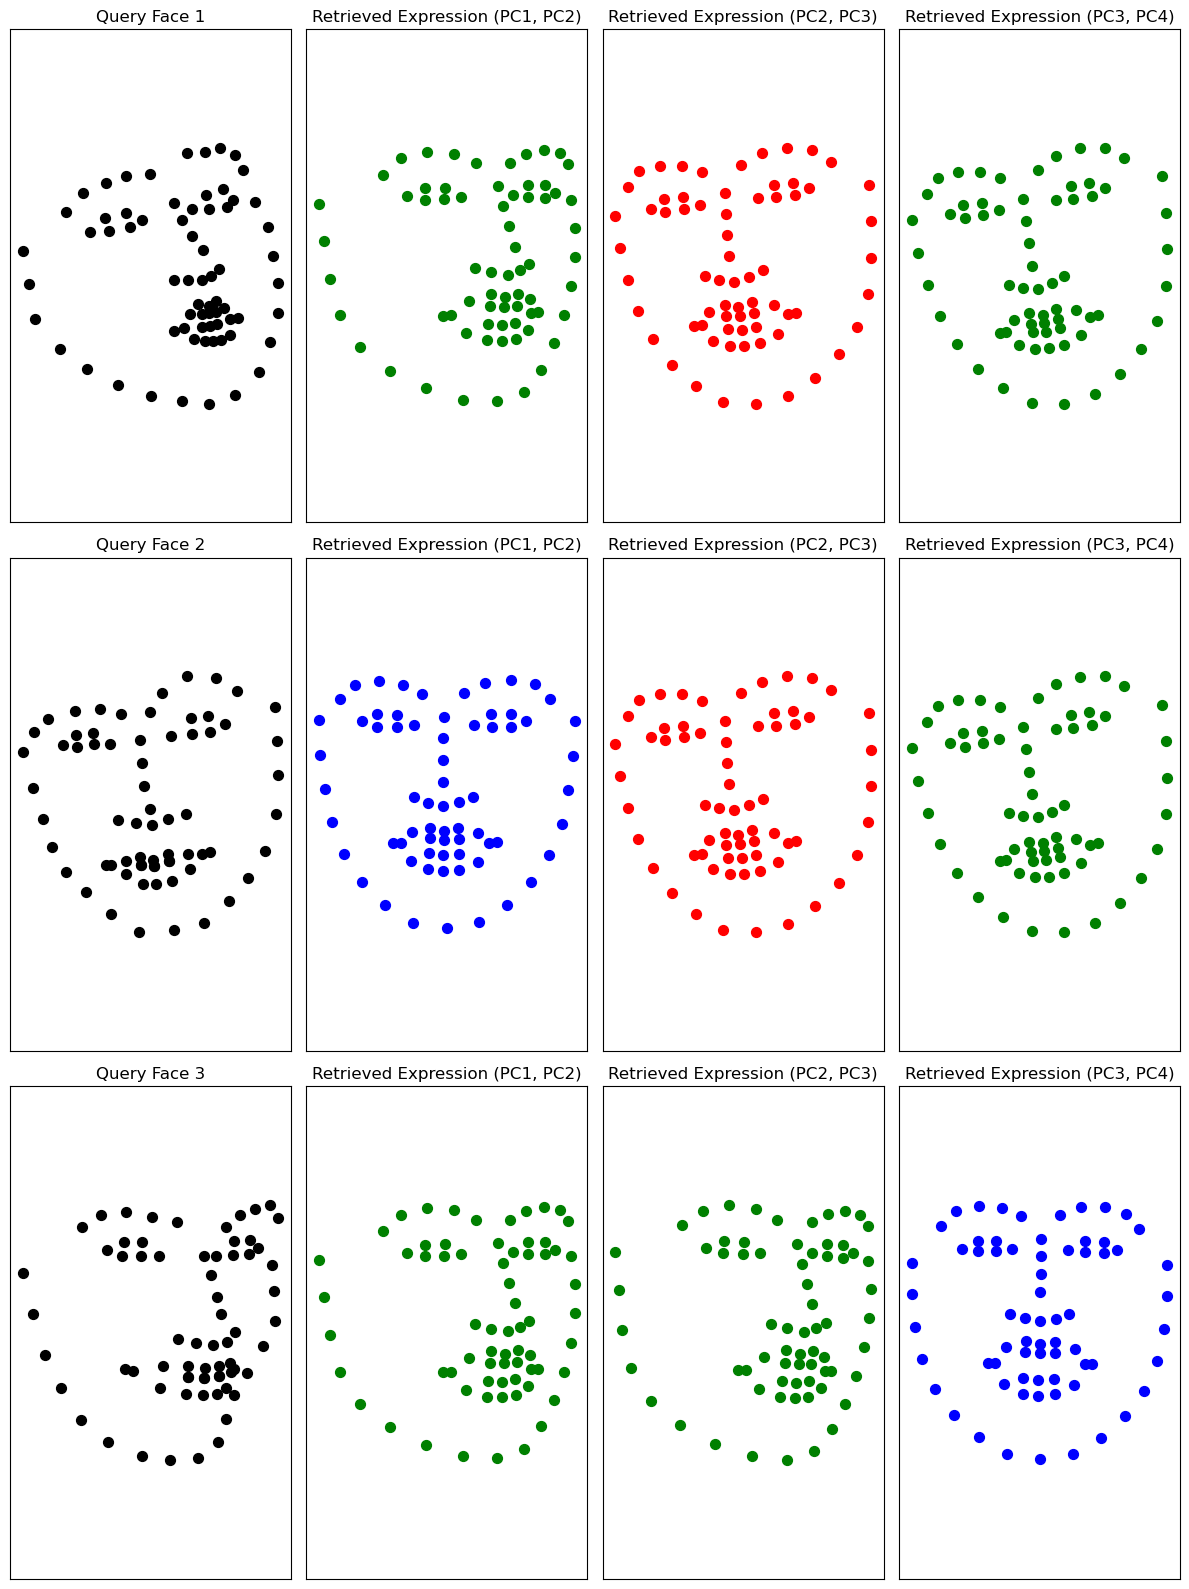

In [15]:
# --------------------------------------
# Add your P3 coding solution below.
# --------------------------------------

def l2(x, y):
    s = 0
    for a, b in zip(x, y):
        s += (a - b)**2
    return math.sqrt(s)

def retrieve_faces(k0, k1, clusters, centers, fdf_test, fdf_train, U, S):
    retrieved_faces = []
    for i in range(fdf_test.shape[1]):
        query_face = fdf_test.iloc[:, i].values
        proj_k0 = np.dot(query_face, U[:, k0]) / S[k0]
        proj_k1 = np.dot(query_face, U[:, k1]) / S[k1]
        query_proj = np.array([proj_k0, proj_k1])
        dists = []
        for c in centers:
            dists.append(l2(query_proj, c))
        match = np.argmin(dists)
        mask = clusters == match
        cluster_faces = fdf_train.iloc[:, mask].values
        avg_face = np.mean(cluster_faces, axis=1)
        retrieved_faces.append((avg_face, query_face, match))
    return retrieved_faces 

latent_pairs = [(0, 1), (1, 2), (2, 3)]
retrieved_faces_per_space = []
for id, (k0, k1) in enumerate(latent_pairs):
    clusters = all_clusters[id]
    centers = all_centers[id]
    retrieved = retrieve_faces(k0, k1, clusters, centers, fdf_test, fdf_train, U, S)
    retrieved_faces_per_space.append(retrieved)
    
colors = ['blue', 'red', 'green']

for row in range(3):
    for col in range(4):
        ax = axes[row, col]
        ax.set_xticks([]) 
        ax.set_yticks([])
        ax.set_aspect('equal')

latent_titles = ["Retrieved Expression (PC1, PC2)",
                 "Retrieved Expression (PC2, PC3)",
                 "Retrieved Expression (PC3, PC4)"]

fig, axes = plt.subplots(3, 4, figsize=(12, 16))

for row in range(3): 
        query_face = retrieved_faces_per_space[0][row][1]
    
        ax = axes[row, 0]
        ax.scatter(query_face[::2], query_face[1::2], c='black', marker='o', s=50)
        ax.set_title(f"Query Face {row + 1}")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect('equal', adjustable='datalim')
    
        for col in range(3):
            avg_face, _, match = retrieved_faces_per_space[col][row]
            ax = axes[row, col + 1]
            ax.scatter(avg_face[::2], avg_face[1::2], c=colors[match], marker='o', s=50)
            ax.set_title(latent_titles[col])
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_aspect('equal', adjustable='datalim')

plt.tight_layout()
plt.show()










    

****

# Image Compression using autoencoders.

Here, you will train an autoencoder neural network for image compression using 14×14 grayscale images of the handwritten digit “5” from the well-known **MNIST** dataset. The training data set (`X_train`) is a $(m,n)$ matrix, where $n=100$ is the total number of images and $m=196$ is the number of pixels. Additionally, the pixel values are normalized to the range $[-1, 1]$.

Your autoencoder uses a three-layer architecture: an **input layer** with 196 units, a **hidden layer** with $\text{h}$ units, and an **output layer** with 196 units. The model is trained using the algorithm described below.

```
Algorithm: train(X, h, epochs, lr)

This algorithm trains the autoencoder model through a sequence of forward passes,
loss computation, backpropagation, and parameter updates.

Arguments:
     X = input data matrix with size (m,n)
     h = number of units in the hidden layer
     epochs = number of training iterations
     lr = learning rate
Return:
     E = final training loss

Note(s):
     - @ is a numpy matrix multiplication.
     - * is a numpy element-wise matrix multiplication
     - + is a numpy element-wise matrix addition (using the numpy broadcasting technique)


// Initialize weight and biases
Initialize the weights using random values from a normal distribution (standard deviation 0.1):
     - W[l=1] is a (h x m) matrix
     - W[l=2] is a (m x h) matrix

Then initialize the bias with zeros:
     - b[1] is a (h x 1) matrix
     - b[2] is a (m x 1) matrix


A[0] = X.T   // holds the input data

Loop number of epochs

    // Compute the neuron output (Z) and corresponding activation (e.g., A=tanh(Z))
    // using feed-forward technique
    Loop l = 1 to 2                            // l is the layer (not including the input layer)
        Z[l] = W[l] @ A[l-1] + b[l]            // if l=1, W is a (h x m) matrix, b is a h dimension vector
                                               // if l=L, W is a (m x h) matrix, b is a m dimension vector
        A[l] = tanh(Z[l])                      // activation function (tanh)
        

    X_hat = A[2]                               // Autoencoder output (approximated input)

    // Compute the autoencoder loss
    E = (1 / (2 * m * n)) * ||X_hat - X||^2    // Loss function is mean square error (MSE) using L2 metric

    // Compute gradients using the back-propagation technique
    Loop l = 2 to 1
        dA[l] = (A[l] - X) / (m * n)           // derivative of the loss function
        dZ[l] = dA[l] * (1 - A[l]^2)           // (1 - A[l]^2) is the derivative of tanh
        dW[l] = dZ[l] @ A[l-1]^T               // Weight gradient
        db[l] = sum(dZ[l])                     // Offset gradient (sum of each row in dZ)


    // For each layer, update the parameters using the gradients
    Loop l = 1 to 2
        W[l] = W[l] - lr * dW[l]               // Update weights
        b[l] = b[l] - lr * db[l]               // Update offsets

end loop


return E
```



In [7]:
X_train = pd.read_csv("X_train.csv" )
X_train

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
1,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
2,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
3,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
4,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
192,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
193,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
194,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0


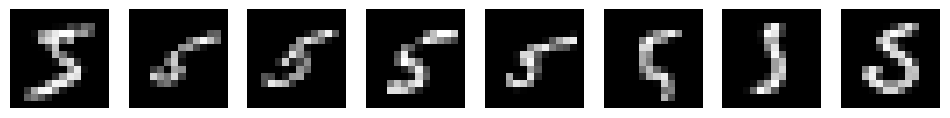

In [8]:
fig, ax = plt.subplots(1, 8, figsize=(12, 3))
for i in range(8):
    ax[i].imshow(X_train[str(i)].to_numpy().reshape(14, 14), cmap="gray", vmin=-1, vmax=1)
    ax[i].axis("off")
plt.show()

**P4** (10 points): Autoencoder Training.

<img src="p4.png" width="500" style="float:right"/>

Train autoencoder models with hidden layer sizes $\text{h} \in \{4, 8, 16, 32\}$ using the provided algorithm on the **X_train** dataset.

For each model, use the hyperparameters $\text{lr} = 2.0$ and $\text{epochs} = 4000$, training on the full dataset.

After training, plot the final training loss vs. the hidden layer size $h$ for each model.

To receive full credit, your solution should produce plots that are comparable to the reference results.

**Notes**
- <span style="background-color: #FFFF00">Your plot won't be identical to the reference one because of the random selection of the initial weights</span>.
- **If you have questions or are unsure, you and your teammates must ask**.

**Plot assumptions**
* The figure has a width of 6 inches and a height of 4 inches.
* The plot color is blue.


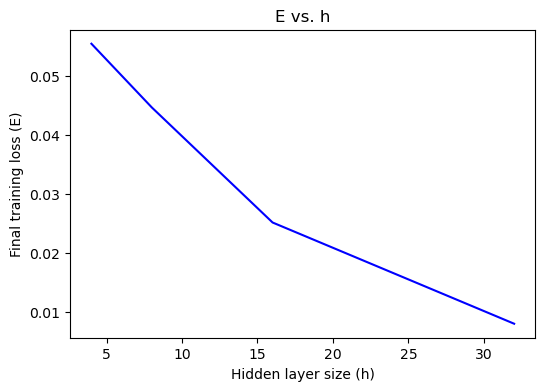

In [9]:
# --------------------------------------
# Add your P4 coding solution below.
# --------------------------------------

def train(X, h, epochs, lr):
    m, n = X.shape
    w1 = np.random.normal(0, 0.1, size=(h, m))
    w2 = np.random.normal(0, 0.1, size=(m, h))
    b1 = np.zeros((h, 1))
    b2 = np.zeros((m, 1))
    for epoch in range(epochs):
        z1 = w1 @ X + b1
        a1 = np.tanh(z1)
        z2 = w2@ a1 + b2
        a2 = np.tanh(z2)
        
        x_hat = a2
        E = (1/(2*m*n)) * np.sum((x_hat - X)**2)
        
        da2 = (a2 - X) / (m*n)
        dz2 = da2 * (1-a2**2)
        dw2 = dz2 @ a1.T
        db2 = np.sum(dz2, axis=1).reshape(-1, 1)

        da1 = w2.T @ dz2
        dz1 = da1 * (1-a1**2)
        dw1 = dz1 @ X.T
        db1 = np.sum(dz1, axis=1).reshape(-1, 1)

        w1 = w1 - lr * dw1
        b1 = b1 - lr * db1

        w2 = w2 - lr * dw2
        b2 = b2 - lr * db2
    return (E, w1, w2, b1, b2)

X = X_train.values

h_sizes = [4, 8, 16, 32]
losses = []

for h in h_sizes:
    output = train(X, h, epochs=4000, lr=2)
    losses.append(output[0])


plt.figure(figsize=(6,4))
plt.plot(h_sizes, losses, color="blue")
plt.title("E vs. h")
plt.xlabel("Hidden layer size (h)")
plt.ylabel("Final training loss (E)")
plt.show()

**P5** (10 points): Autoencoder analysis.

Using the `h=32` trained autoencoder model generated above and the `X_test` dataset, create the provided reference plot. The test data set (`X_test`) is an $(m,n)$ matrix, where $n=8$ is the total number of images and $m=196$ is the number of pixels per image. Additionally, the pixel values are normalized to the range $[-1, 1]$.

To recreate the reference plot, for each image in `X_test`; 
- The 1st row shows the original test images (each image $X$ is a 14x14 matrix).
- The 2nd row shows the compressed representation (each representation is a 4x8 matrix).
- The 3rd row shows the decompressed images (each image $X_{out}$ is a 14x14 matrix).
- The 4th row shows the error image $|X_{out}-X|$ (each image is a 14x14 matrix).

<img src="p5.png" width="900"/>

**Plot assumptions**

* Your figure should be 12 inches by 6 inches.
* For the first three rows, the [imshow](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html)  function requires these arguments (cmap="gray", vmin=-1, vmax=1)
* For the last row, the [imshow](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html)  function requires these arguments (cmap="gray", vmin=0, vmax=1)
* Use [numpy.reshape](https://numpy.org/doc/stable/reference/generated/numpy.reshape.html) to convert flattened vectors into 2D matrix form for visualization.

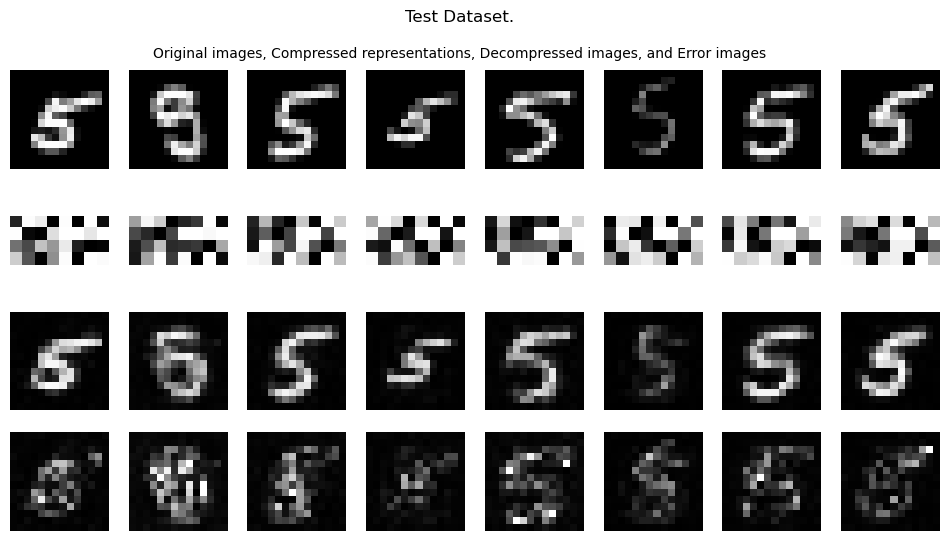

In [10]:

X_test = pd.read_csv("X_test.csv" )

# --------------------------------------
# Add your P5 coding solution below.
# --------------------------------------
X = X_train.values
X_test = X_test.values
output = train(X, h=32, epochs=4000, lr=2)
E, w1, w2, b1, b2 = output[0], output[1], output[2], output[3], output[4]

z1 = w1 @ X_test + b1
a1 = np.tanh(z1)
z2 = w2 @ a1 + b2
a2 = np.tanh(z2)

fig, ax = plt.subplots(4, 8, figsize=(12, 6))

for i in range(8):
    ax[0, i].imshow(X_test[:, i].reshape(14, 14), cmap="gray", vmin=-1, vmax=1)
    ax[1, i].imshow(a1[:, i].reshape(4, 8), cmap="gray", vmin=-1, vmax=1)
    ax[2, i].imshow(a2[:, i].reshape(14, 14), cmap="gray", vmin=-1, vmax=1)

    error = np.abs(a2[:, i] - X_test[:, i]).reshape(14, 14)
    ax[3, i].imshow(error, cmap="gray", vmin=0, vmax=1)

    ax[0, i].axis("off")
    ax[1, i].axis("off")
    ax[2, i].axis("off")
    ax[3, i].axis("off")
fig.suptitle("Test Dataset.")
fig.text(0.5, 0.9, "Original images, Compressed representations, Decompressed images, and Error images", ha="center")
plt.show()









